In [14]:
import pygmt
import harmonica as hm
import numpy as np

# O campo magnético da Terra

- Sua intensidade varia espacialmente;

- Tem uma variação temporal também, em diferentes escalas:
    - diurnal;
    - secular ou deriva para oeste;
    - reversões

- Possui uma declinação: ângulo entre o norte geografíco e a direção do campo;

- Possui uma inclinação: ângulo entre a horizontal e a direção do campo;

- É aproximadamente dipolar que decai com o tempo;

- Ele magnetiza rochas gerando remanencia (quando a rocha grava o campo em um momento do tempo);

- O campo do núcleo é gerado pelo geodínamo;

- O campo crustal é gerado por minerais magnéticos e eles podem ter duas caracteristicas:
    - Remanência (quando o campo do passado fica gravado);
    - Indução (quando o campo atual induz uma magnetização naquela rocha);

- O campo externo é gerado pela magnetização da ionosfera por paticulas solares carregadas;

- Tem feições caracteristicas:
    - Anomalia do Atlântico Sul
    - Migração dos Polos (Alto da Sibéria)

In [15]:
# Vamos usar o harmonica para calcular o IGRF 
igrf = hm.IGRF14(date='2005-07-02T04:57:00')

In [16]:
# Vamos fazer o grid do IGRF
campo = igrf.grid(region=[0, 360, -90,90], height=1000, spacing=0.3)
display(campo)

<xarray.Dataset> Size: 23MB
Dimensions:    (latitude: 601, longitude: 1201)
Coordinates:
  * latitude   (latitude) float64 5kB -90.0 -89.7 -89.4 -89.1 ... 89.4 89.7 90.0
  * longitude  (longitude) float64 10kB 0.0 0.3 0.6 0.9 ... 359.4 359.7 360.0
    height     (latitude, longitude) float64 6MB 1e+03 1e+03 ... 1e+03 1e+03
Data variables:
    b_east     (latitude, longitude) float64 6MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    b_north    (latitude, longitude) float64 6MB 1.455e+04 ... 1.853e+03
    b_up       (latitude, longitude) float64 6MB 5.298e+04 ... -5.645e+04
Attributes:
    Conventions:  CF-1.8
    title:        IGRF14 magnetic field on 2005-07-02T04:57:00
    crs:          WGS84
    source:       Generated by spherical harmonic synthesis using library Har...
    description:  Three components of the magnetic field vector calculated on...
    units:        nT
    date:         2005-07-02T04:57:00
    references:   https://doi.org/10.5281/zenodo.14218973

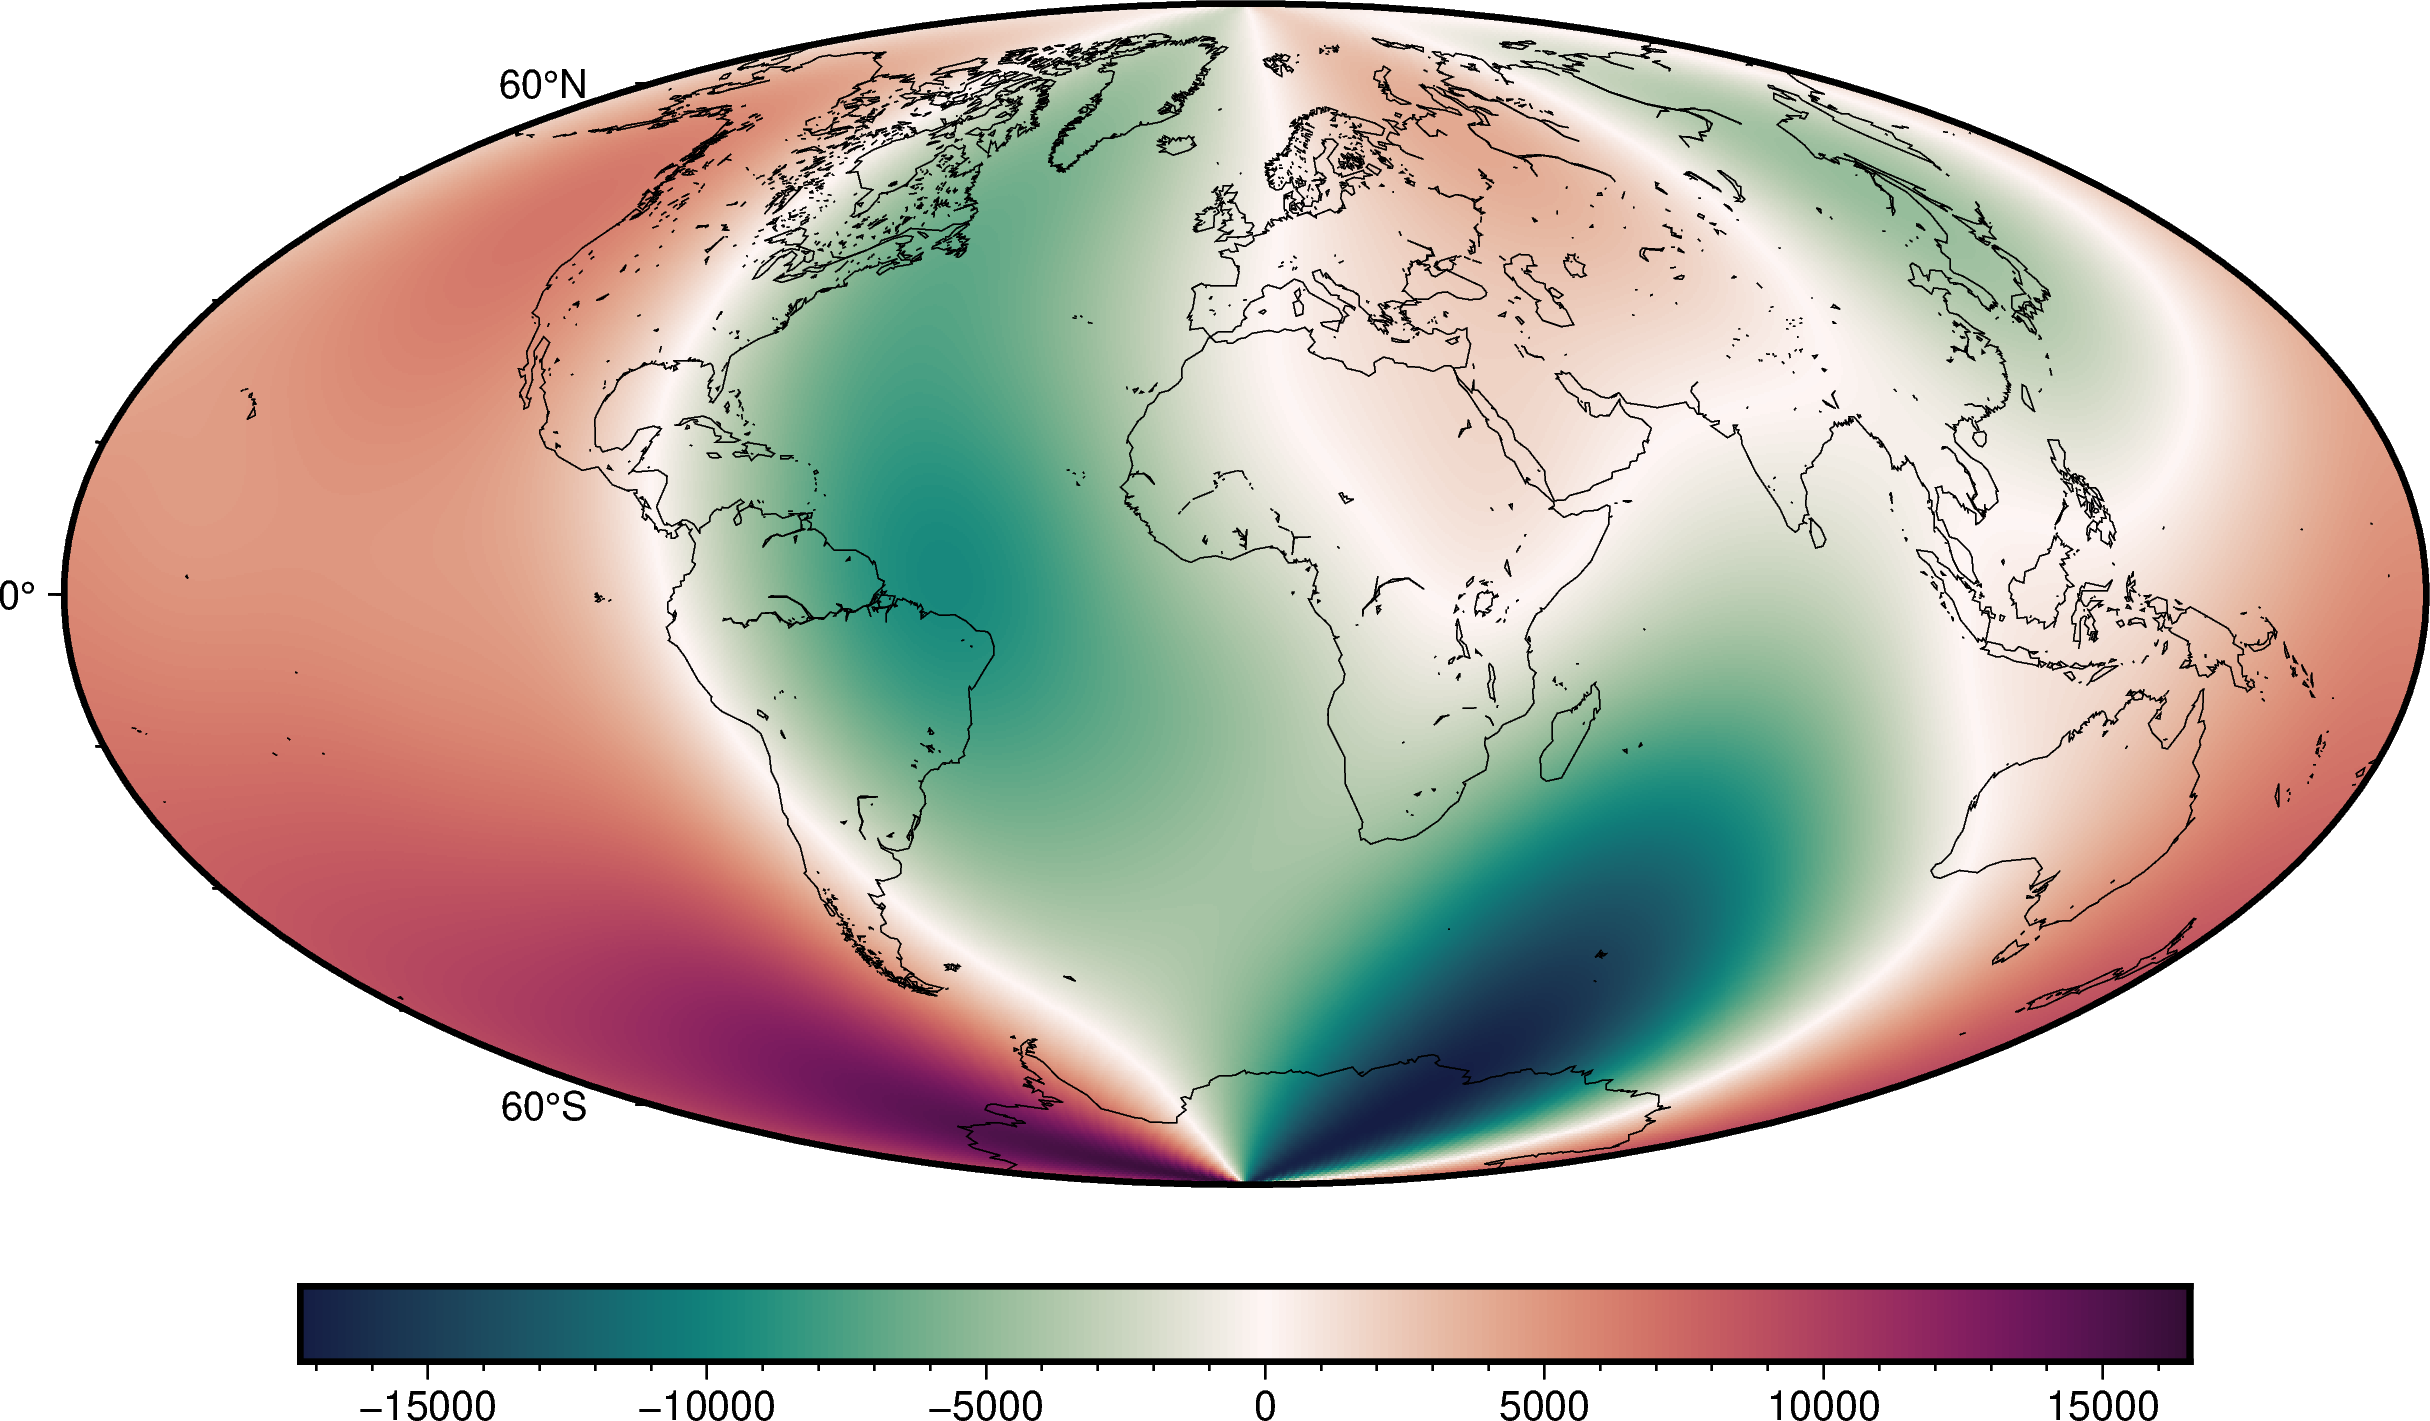

In [17]:
# Agora vamos usar o pygmt para plotar nossas componentes do IGRF, começamos com B leste
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    campo.b_east, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)

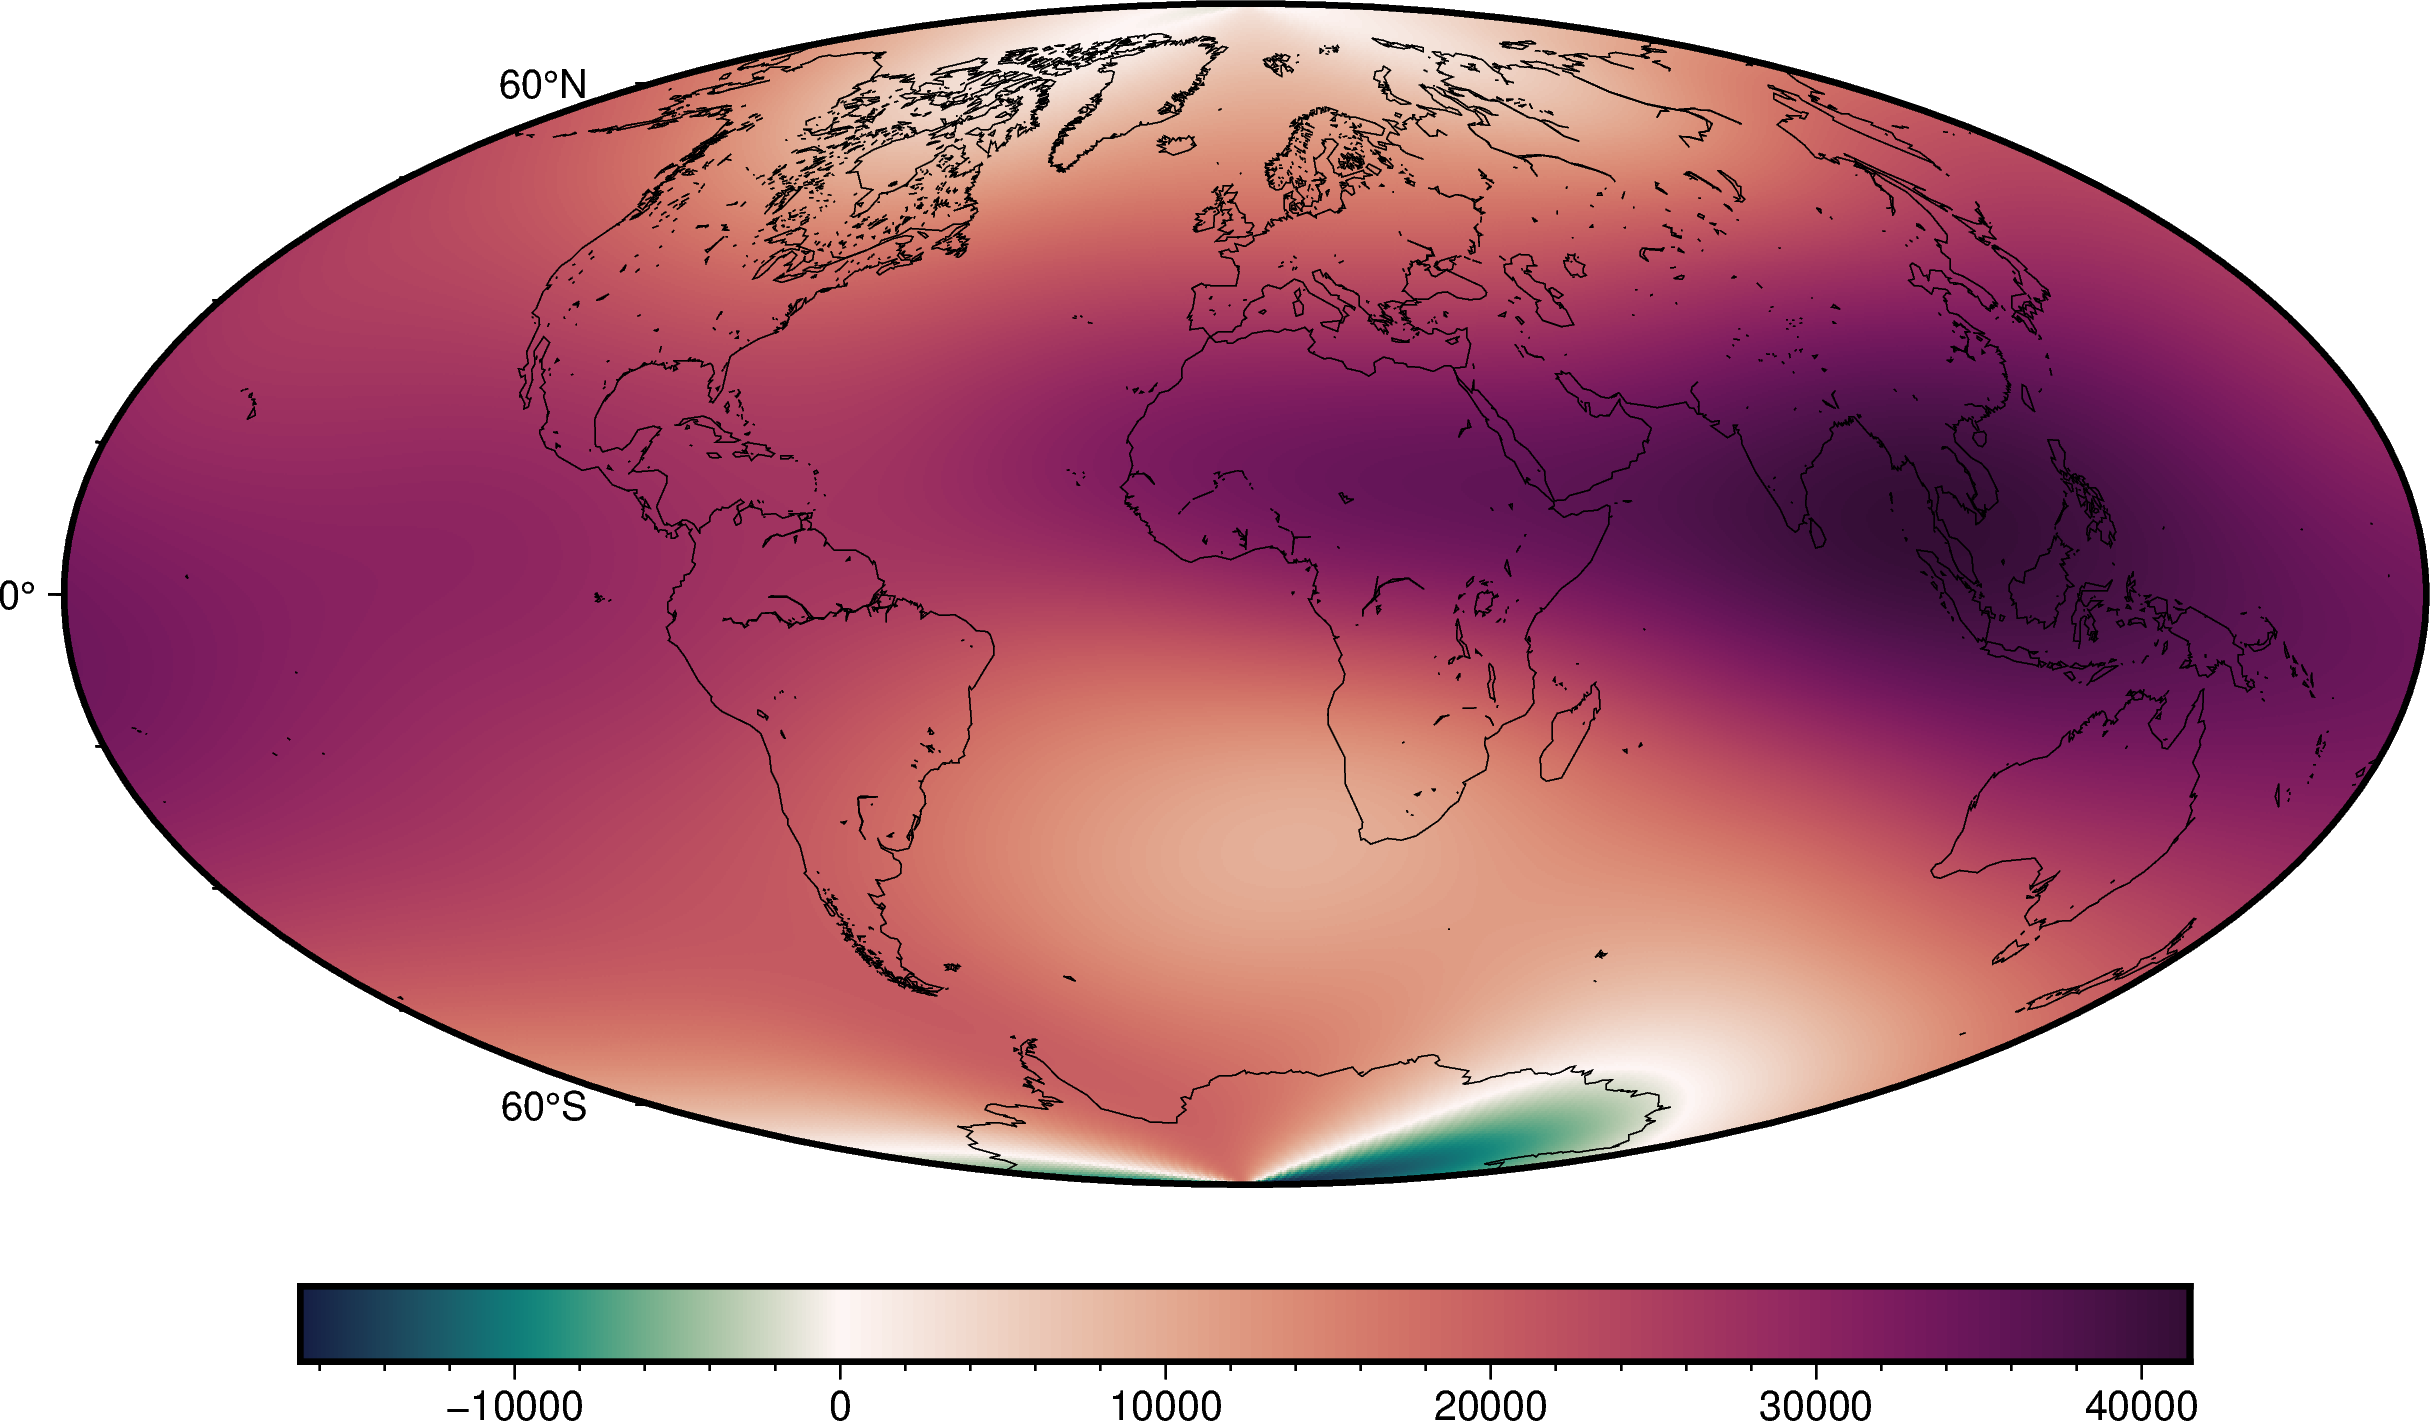

In [18]:
# Agora B norte
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    campo.b_north, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)

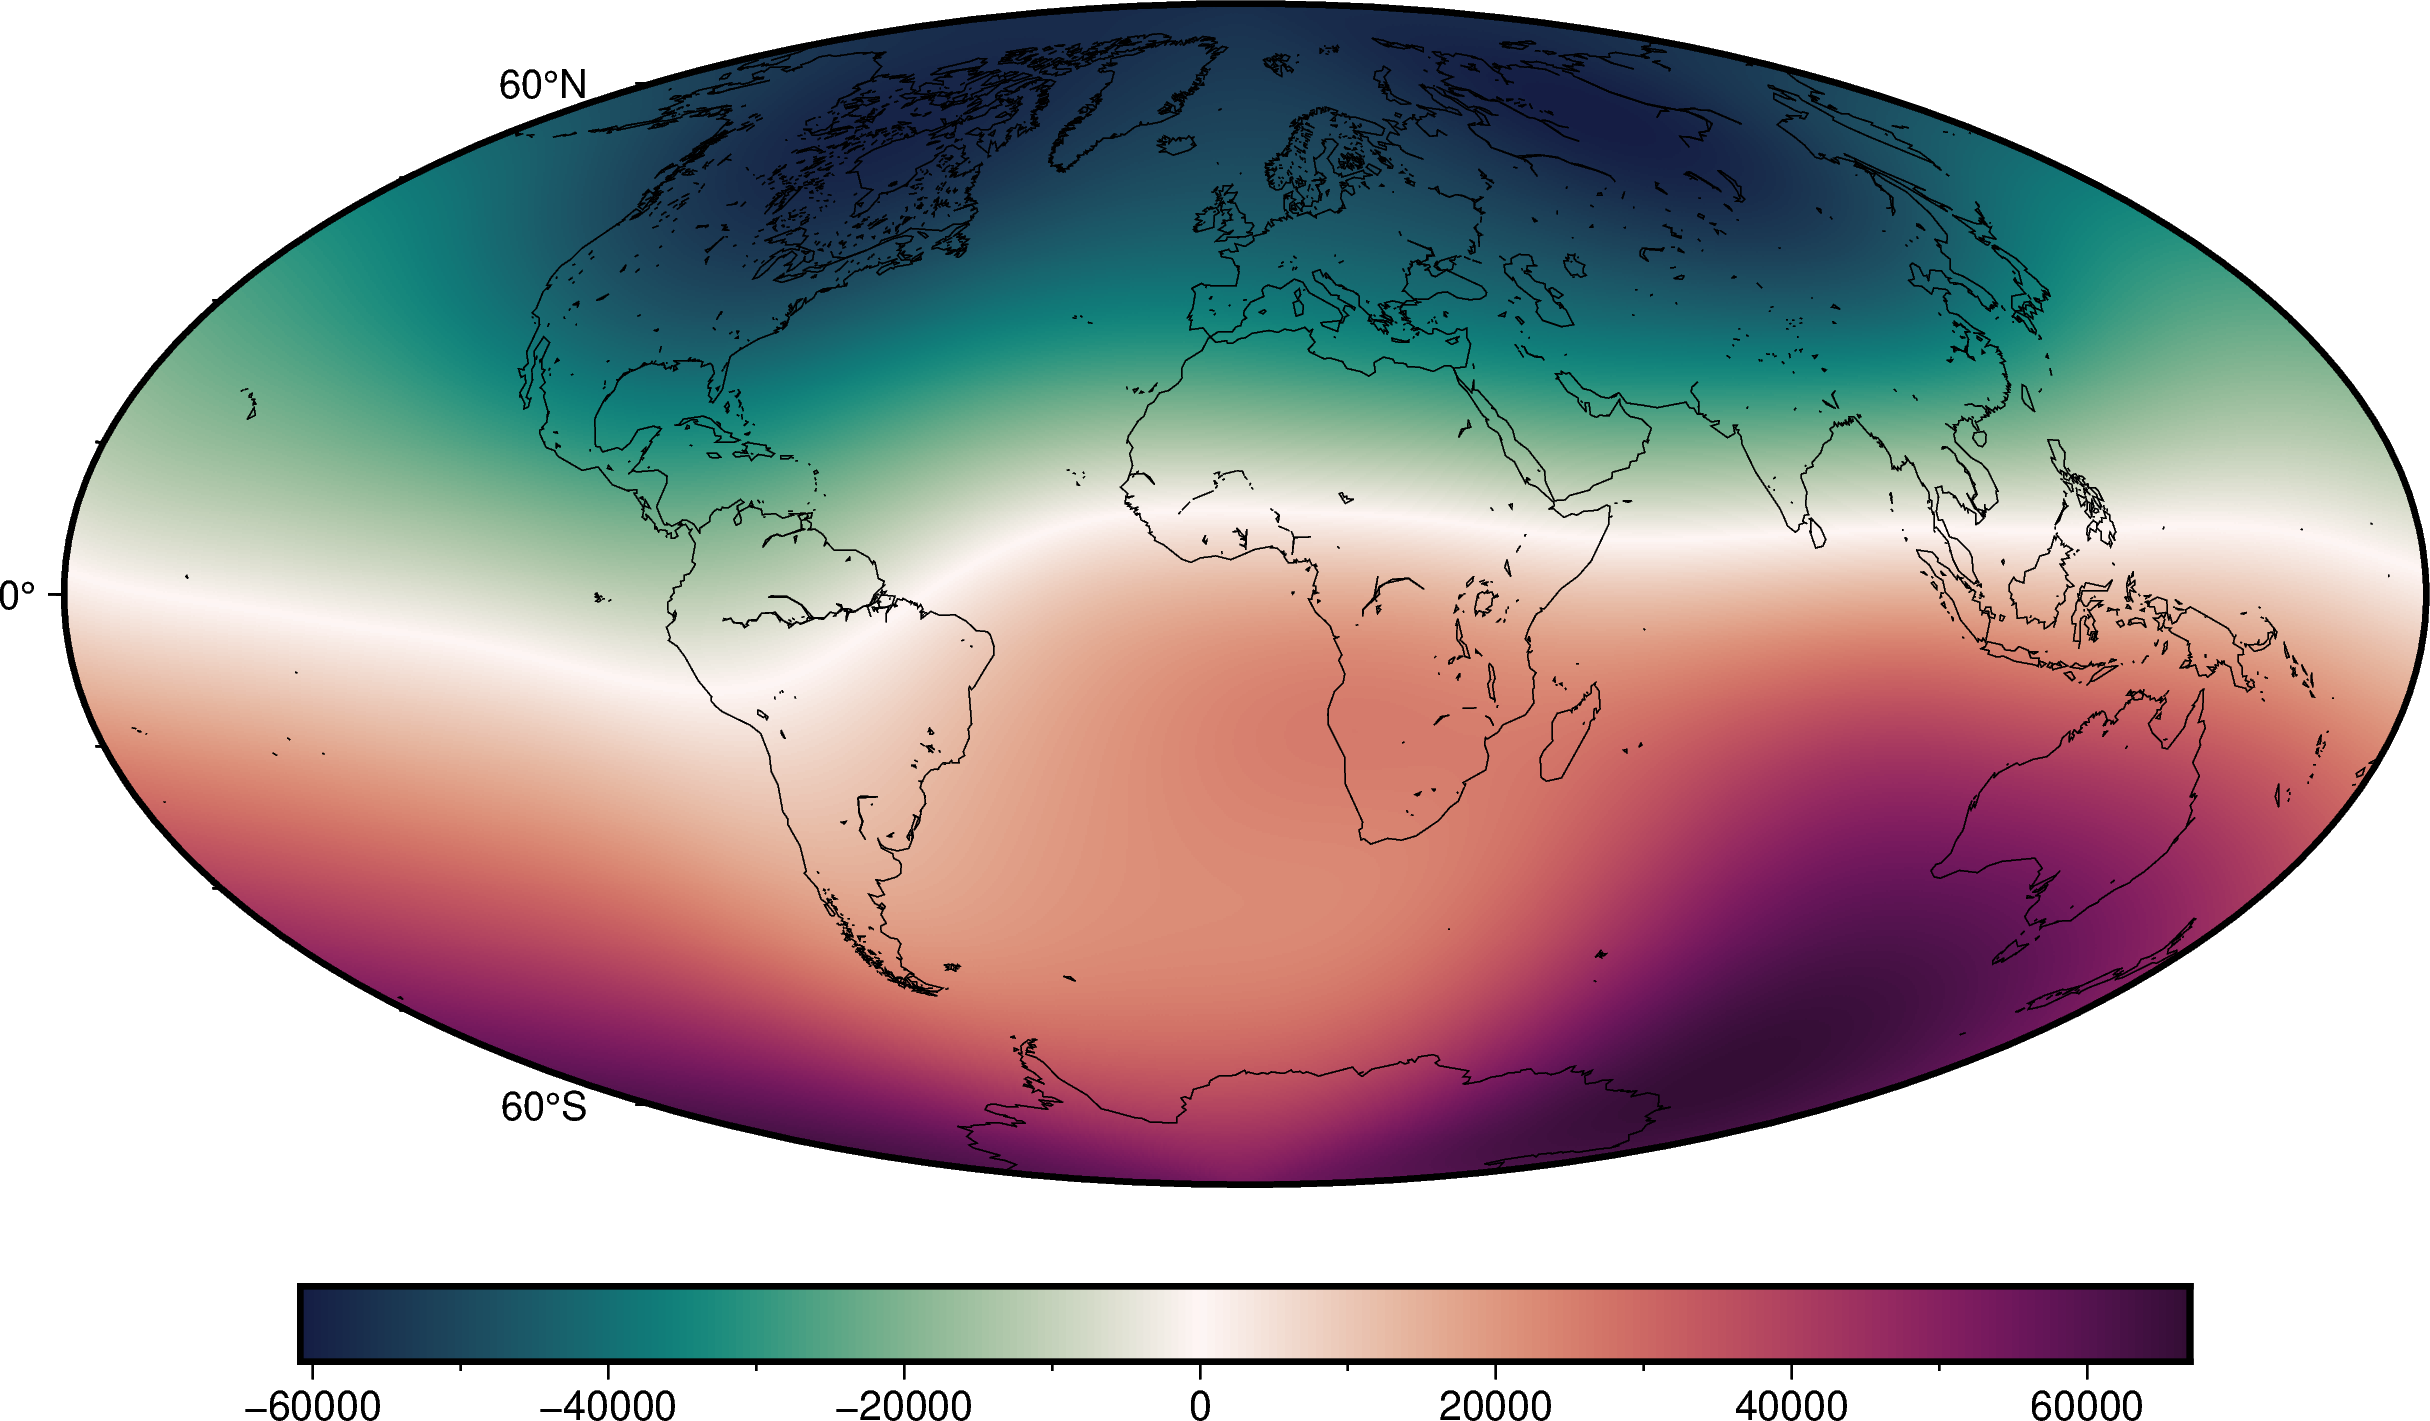

In [19]:
# Por fim B cima
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    campo.b_up, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)

In [31]:
# Vamos escrever o campo em termos da sua amplitude, inclinação e declinação
amplitude, inc, dec = hm.magnetic_vec_to_angles(
    campo.b_east, campo.b_north, campo.b_up
)

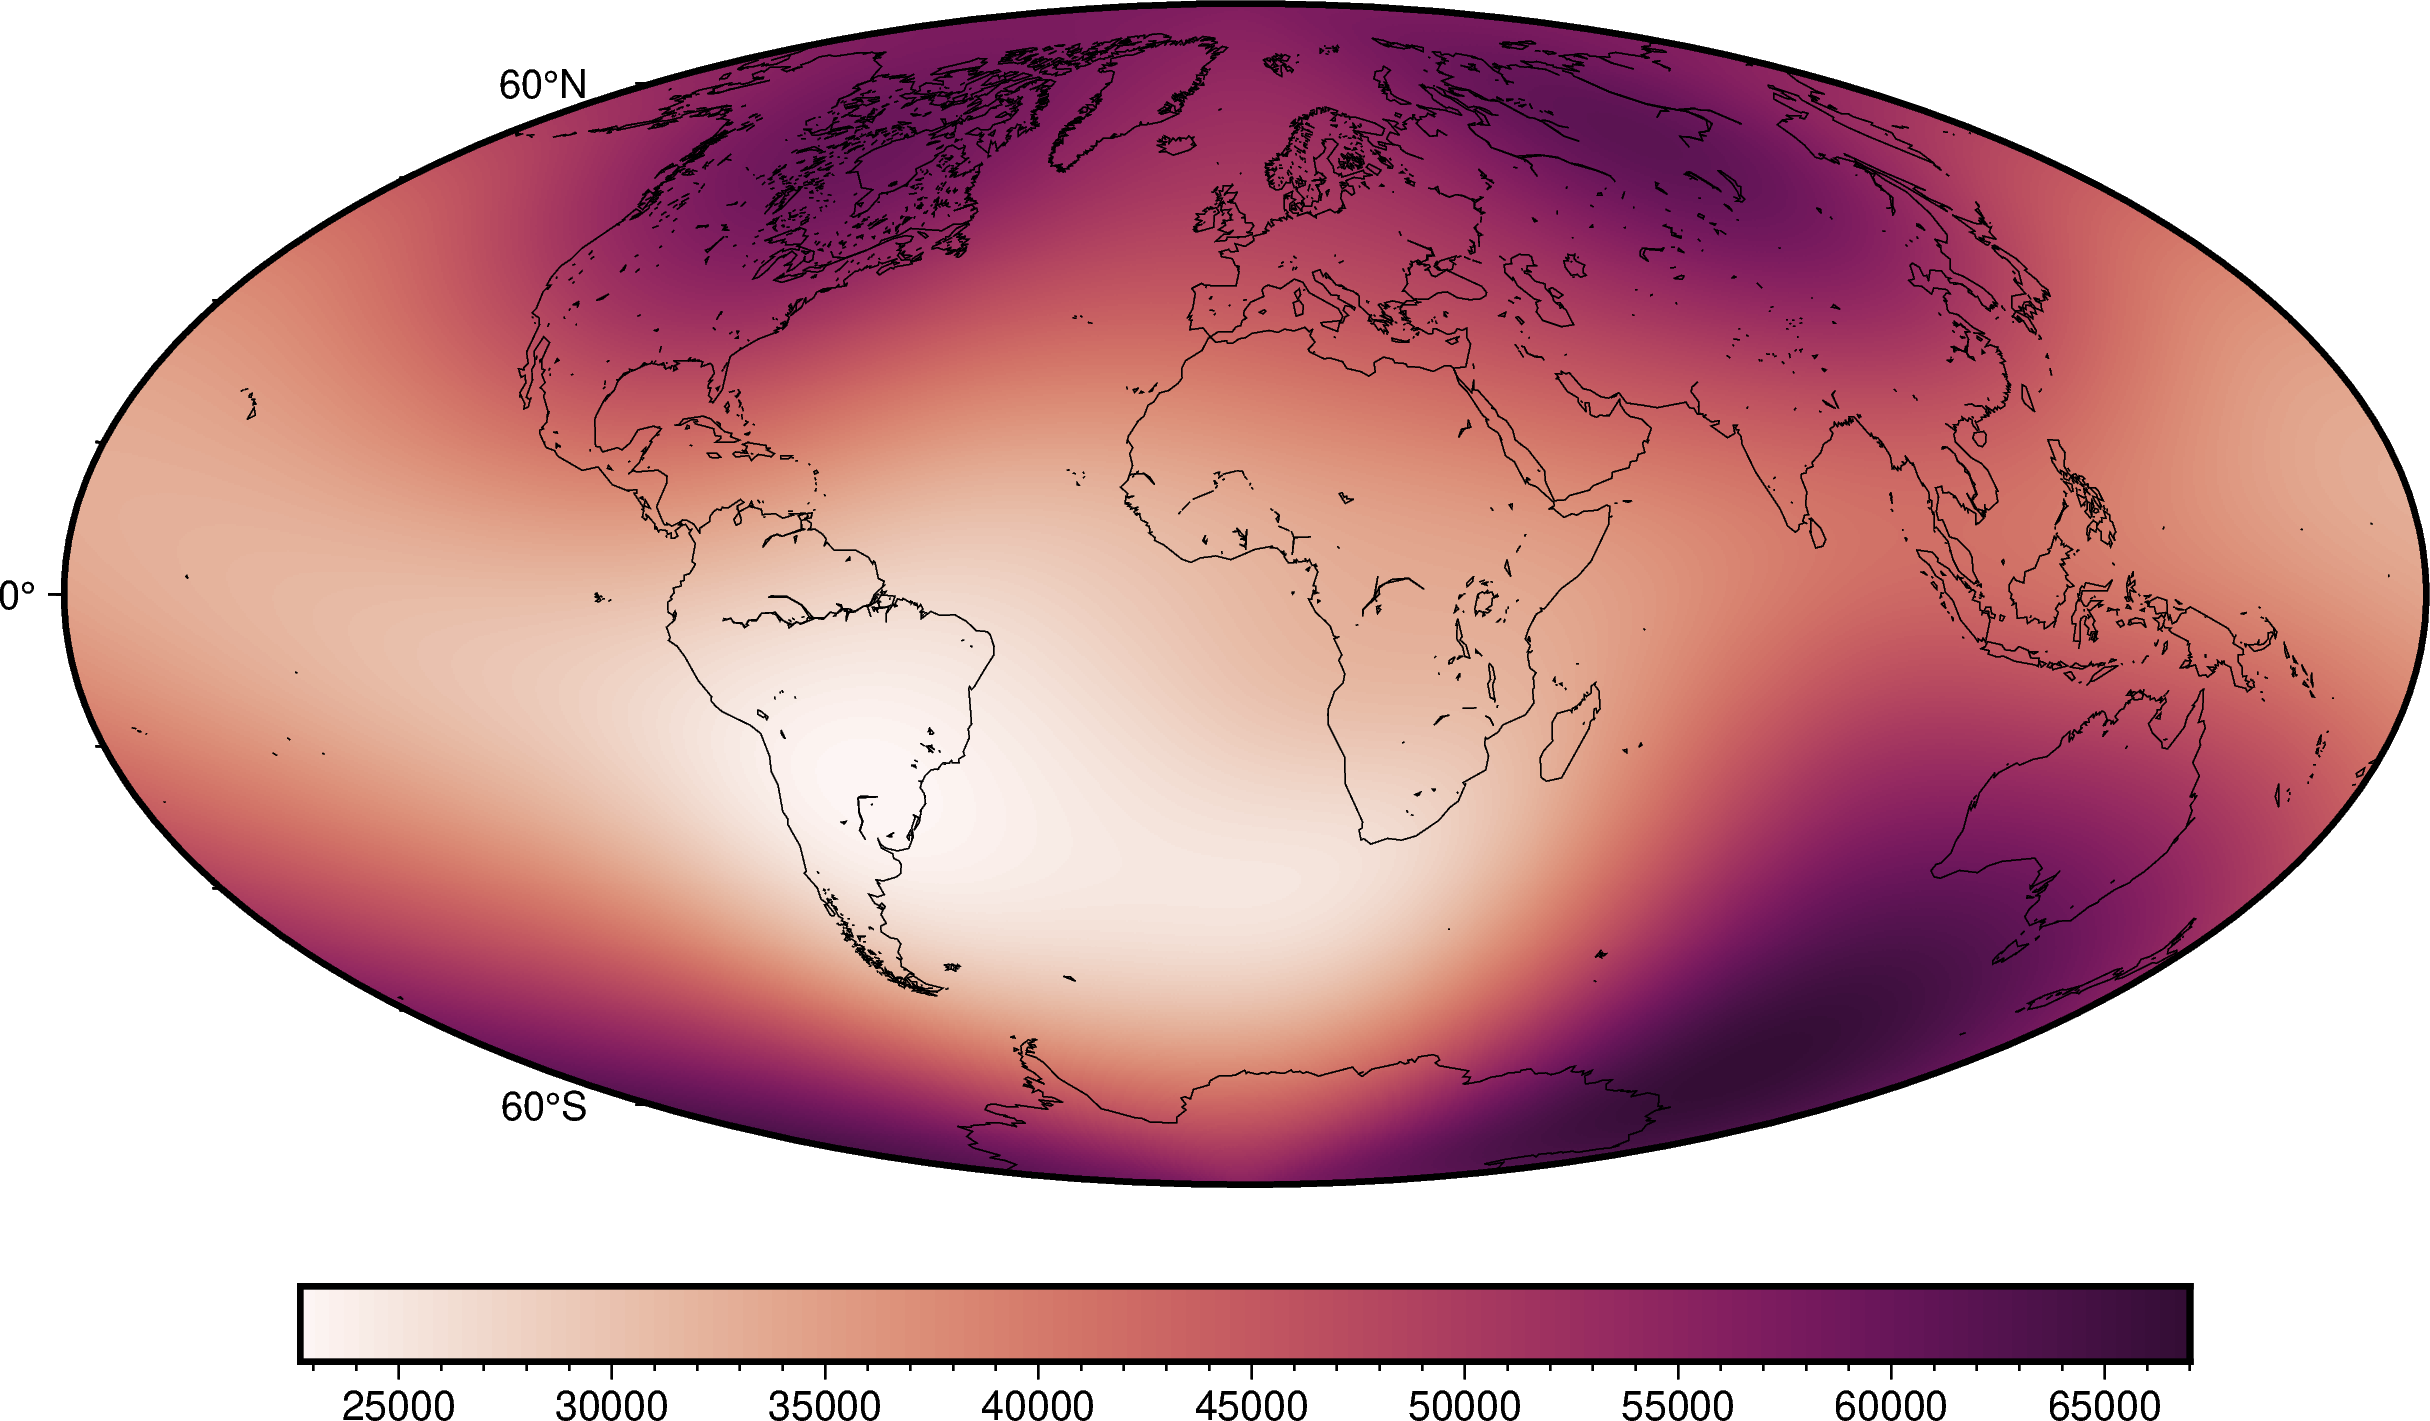

In [32]:
# Vamos plotar a amplitude, inclinação e declinação
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    amplitude, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)

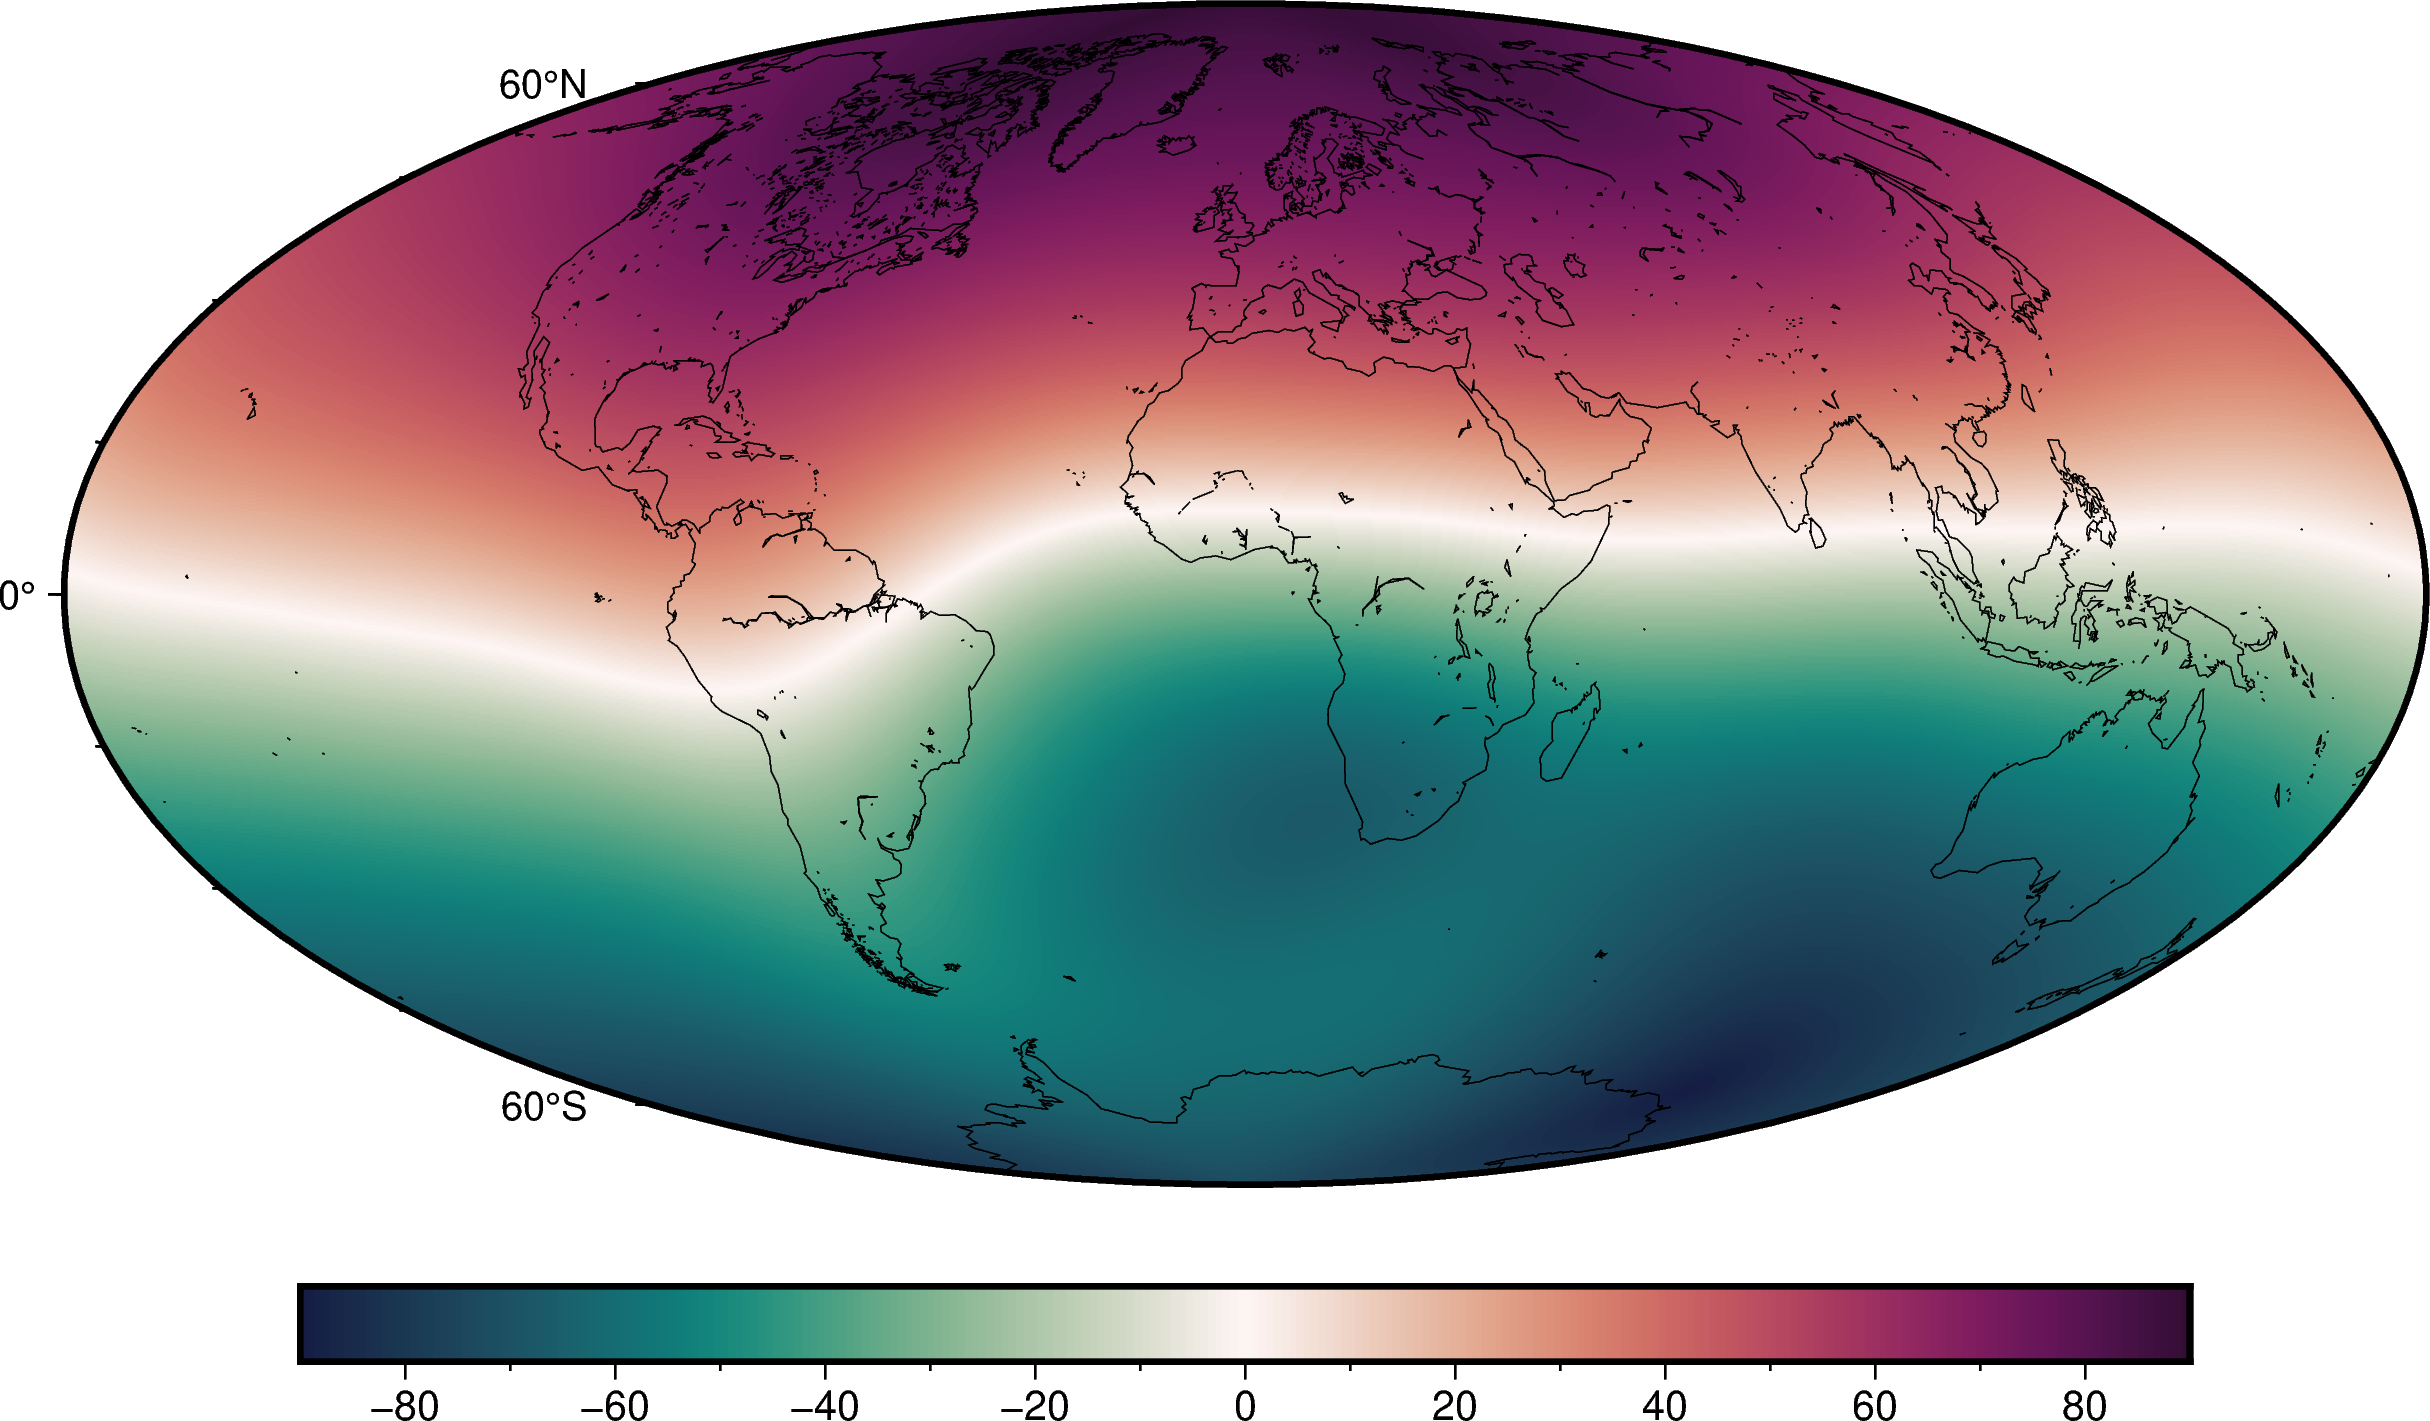

In [33]:
# Vamos plotar a amplitude, inclinação e declinação
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    inc, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)

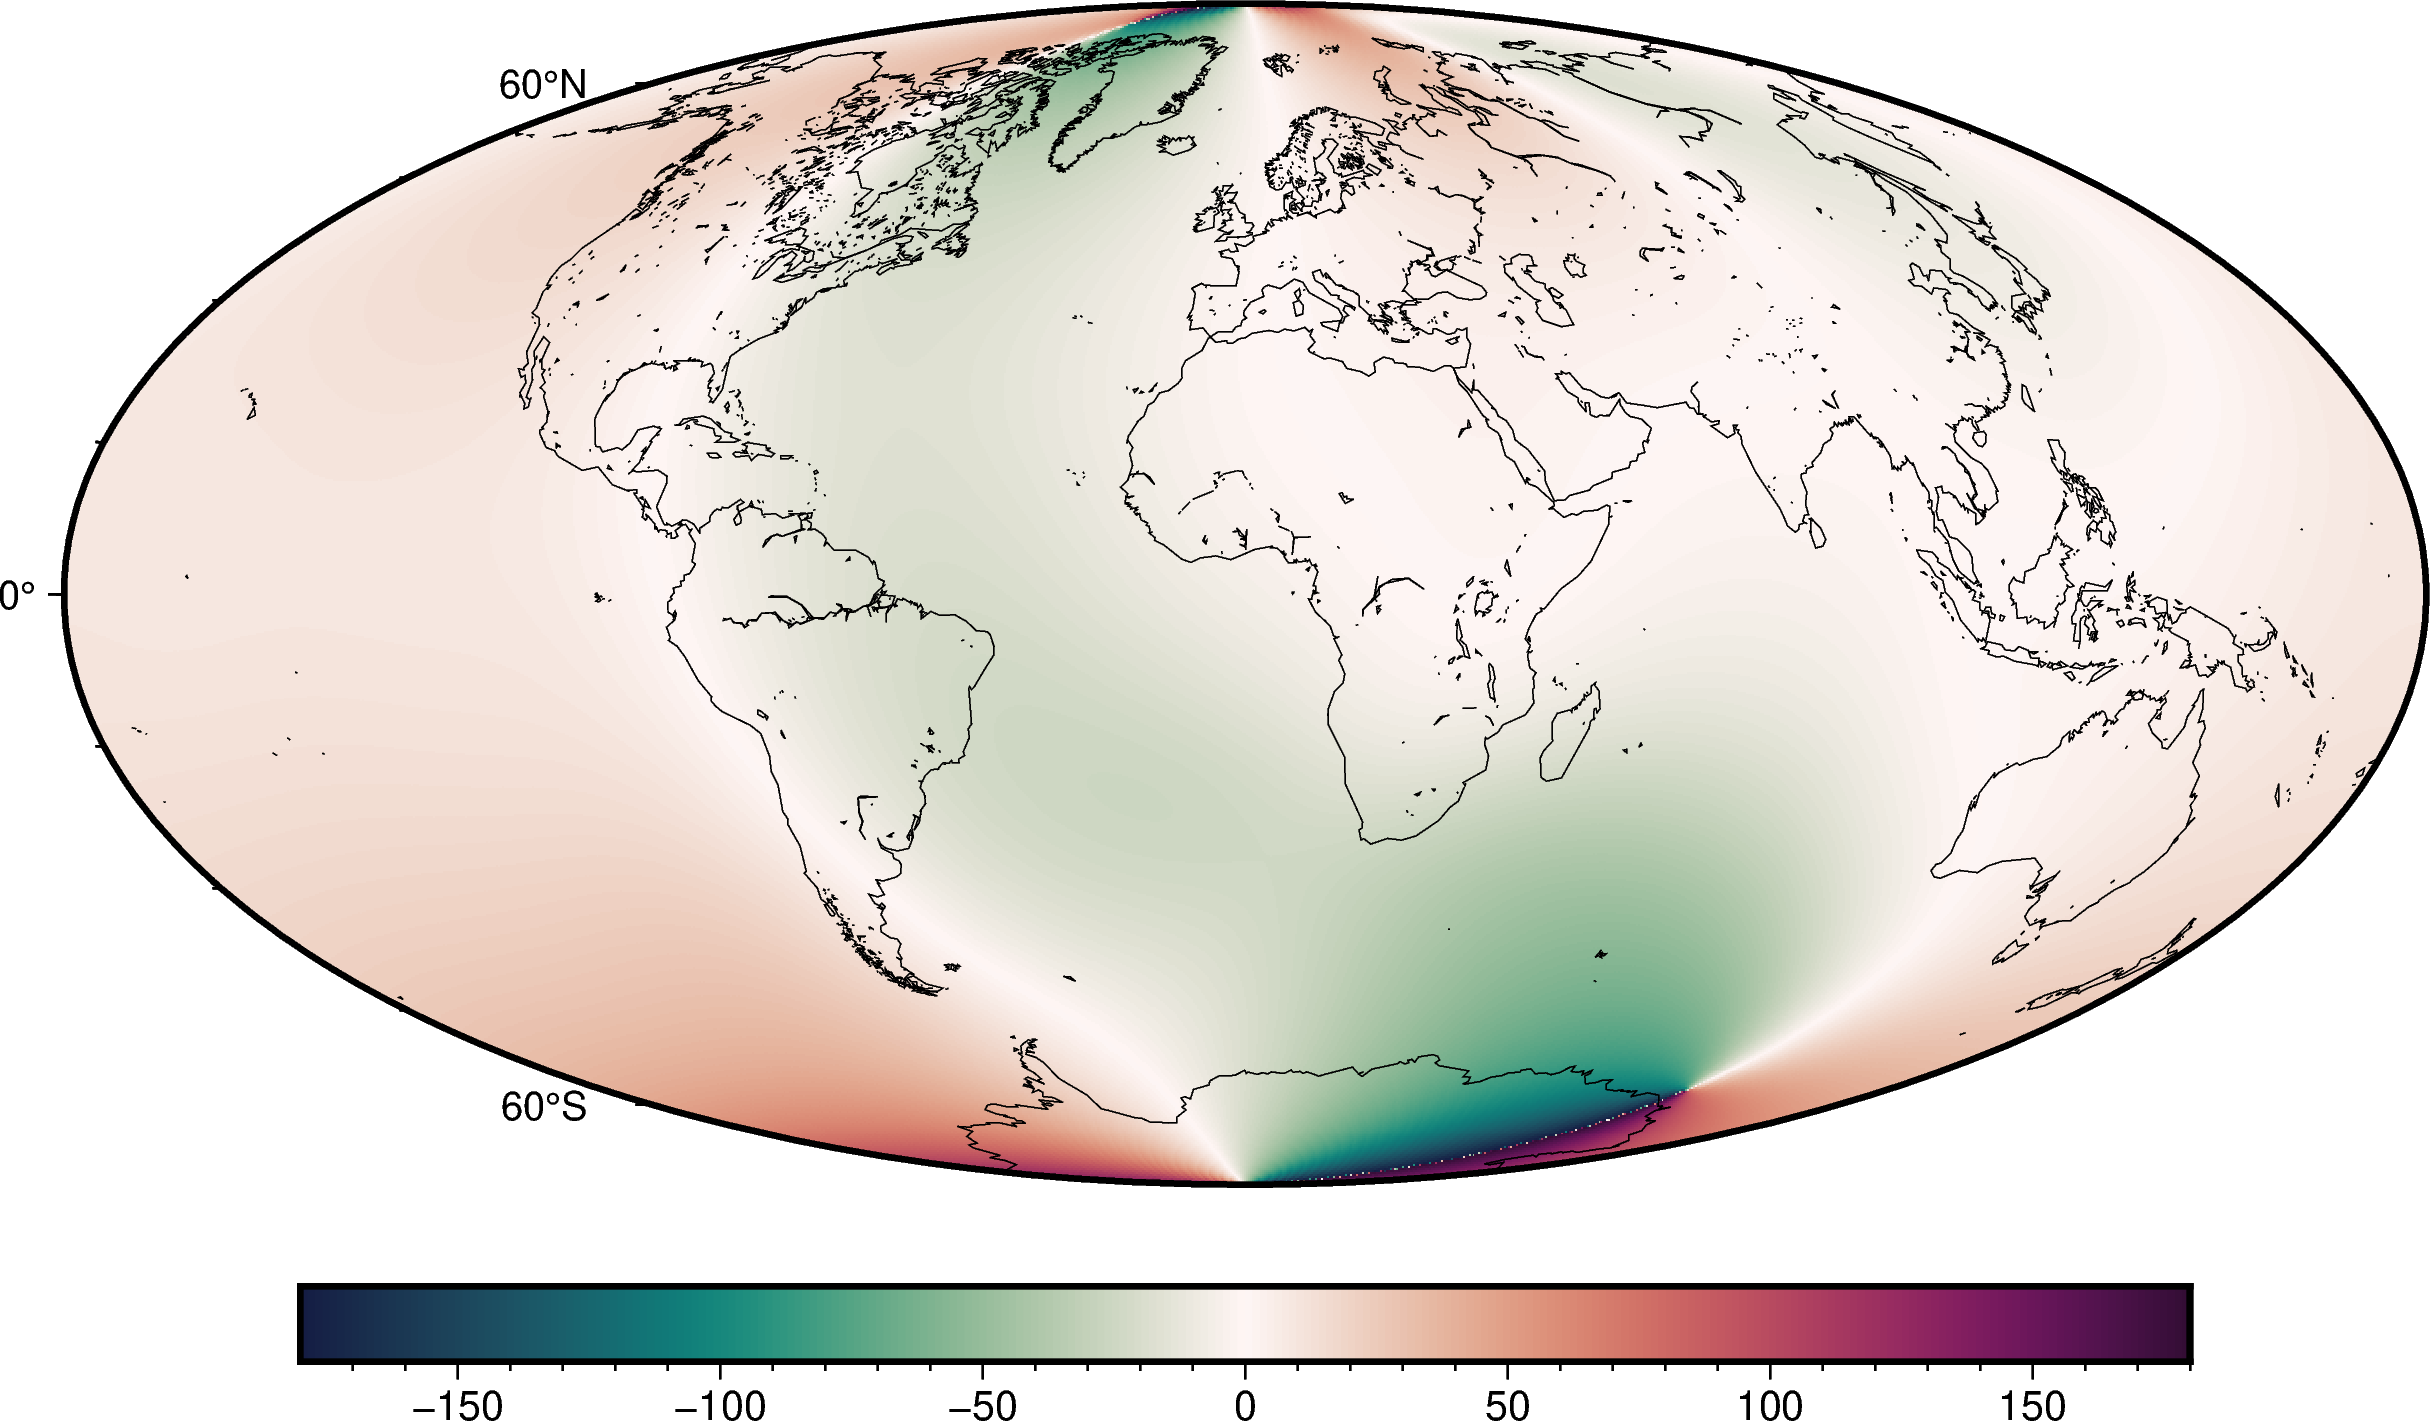

In [34]:
# Vamos plotar a amplitude, inclinação e declinação
fig = pygmt.Figure()
#Plotando os dados da malha
fig.grdimage(
    dec, 
    projection="H0/20c",
    cmap="curl+h",
)
#Plotando a linha de costa e os "ticks" do mapa
fig.coast(shorelines=True, frame=True)
#Plotando uma barra de cores para nosso mapa
fig.colorbar()
#Mostrando a figura, o argumento width aumenta o tamanho de exibição da imagem
fig.show(width=1000)